In [1]:
import xarray as xr
import glob

In [2]:
# Get all monthly files
files_le = sorted(glob.glob("latent-heat-flux-northward_monthly_2022*_v1.0.nc"))
files_te = sorted(glob.glob("total-energy-flux-northward_monthly_2022*_v1.0.nc"))

# Open and combine along time
ds_le = xr.open_mfdataset(files_le, combine="by_coords")
ds_te = xr.open_mfdataset(files_te, combine="by_coords")


# Compute time mean
lhfln_mean = ds_le["lhfln"].mean(dim="time")
tefln_mean = ds_te["tefln"].mean(dim="time")

In [3]:
lhfln_mean

<xarray.DataArray 'lhfln' (latitude: 721, longitude: 1440)> Size: 4MB
dask.array<mean_agg-aggregate, shape=(721, 1440), dtype=float32, chunksize=(721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 3kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

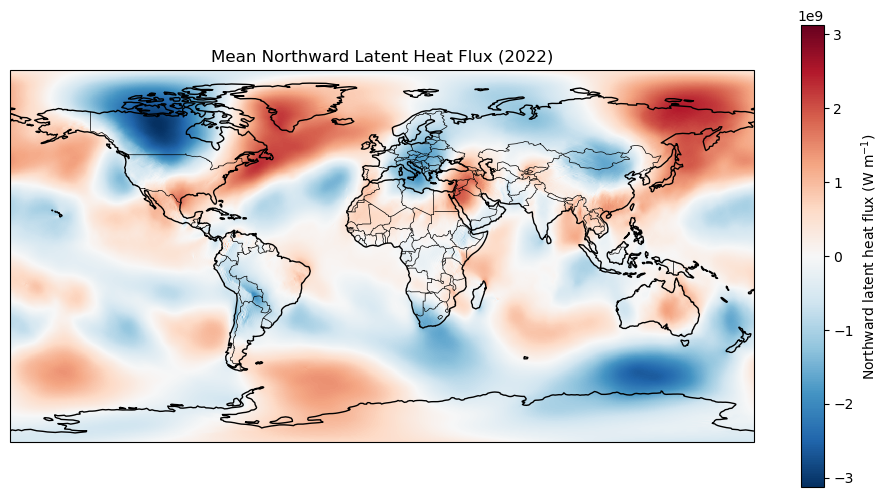

In [7]:
fig = plt.figure(figsize=(12, 6))

ax = plt.axes(projection=ccrs.PlateCarree())

MSE=lhfln_mean_computed+tefln_mean_computed

# Plot
MSE.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    cbar_kwargs={
        "label": "Northward latent heat flux (W m$^{-1}$)"
    }
)

# Map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_global()

ax.set_title("Mean Northward Latent Heat Flux (2022)")

plt.show()

In [ ]:
# lhfln_mean_zonal_mean = lhfln_mean_computed.mean(dim="longitude")

# import matplotlib.pyplot as plt

# fig, ax = plt.subplots(figsize=(6, 8))

# ax.plot(
#     lhfln_mean_zonal_mean,
#     lhfln_mean_zonal_mean.latitude,
#     linewidth=2,
#     color="black"
# )

# # Zero line
# ax.axvline(0, linestyle="--", linewidth=1)

# # Labels
# ax.set_xlabel("Northward latent heat flux (W m$^{-1}$)")
# ax.set_ylabel("Latitude (°N)")
# ax.set_title("Zonal-Mean Northward Latent Heat Flux (2022)")

# # Grid
# ax.grid(True, linestyle=":", alpha=0.6)

# # Latitude limits
# ax.set_ylim(-90, 90)

# plt.tight_layout()
# plt.show()

In [ ]:
lhfln_mean_zonal_mean = lhfln_mean_computed.mean(dim="longitude")
tefln_mean_zonal_mean = tefln_mean_computed.mean(dim="longitude")


import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    lhfln_mean_zonal_mean.latitude,
    lhfln_mean_zonal_mean,
    linewidth=2.5,
    label="Latent heat flux",
    color="tab:blue"
)

# ax.plot(
#     tefln_mean_zonal_mean.latitude,
#     tefln_mean_zonal_mean,
#     linewidth=2.5,
#     label="Total energy flux",
#     color="tab:red"
# )

# Zero line
ax.axhline(0, linestyle="--", linewidth=1)

# Labels
ax.set_xlabel("Latitude (°N)")
ax.set_ylabel("Northward flux (W m$^{-1}$)")
ax.set_title("Zonal-Mean Northward Latent Heat Flux (2022)")

# Limits and grid
ax.set_xlim(-90, 90)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
%store lhfln_mean_zonal_mean